In [2]:
import pandas as pd
import json
from datetime import datetime

bio = pd.read_csv('raw/athlete_bio.csv')
results = pd.read_csv('raw/athlete_results.csv')
games = pd.read_csv('raw/games.csv')

paris_athletes = pd.read_csv('raw/paris_athletes.csv')
paris_medals = pd.read_csv('raw/paris_medals.csv')
paris_events = pd.read_csv('raw/paris_events.csv')

In [9]:
bio.head()
results.head()
games.head()

,edition,edition_id,edition_url,year,city,country_flag_url,country_noc,start_date,end_date,competition_date,isHeld
0,1896 Summer Olympics,1,/editions/1,1896,Athina,https://olympedia-flags.s3.eu-central-1.amazon...,GRE,6 April,15 April,6 – 13 April,NaN
1,1900 Summer Olympics,2,/editions/2,1900,Paris,https://olympedia-flags.s3.eu-central-1.amazon...,FRA,NaN,NaN,14 May – 28 October,NaN
2,1904 Summer Olympics,3,/editions/3,1904,St. Louis,https://olympedia-flags.s3.eu-central-1.amazon...,USA,14 May,NaN,1 July – 26 November,NaN
3,1908 Summer Olympics,5,/editions/5,1908,London,https://olympedia-flags.s3.eu-central-1.amazon...,GBR,13 July,25 July,27 April – 31 October,NaN
4,1912 Summer Olympics,6,/editions/6,1912,Stockholm,https://olympedia-flags.s3.eu-central-1.amazon...,SWE,6 July,15 July,5 May – 27 July,NaN


In [10]:
historico = results.merge(bio, on="athlete_id", how="left")
historico = historico.merge(games, on="edition_id", how="left")

In [11]:
historico = historico.drop_duplicates()
historico = historico.dropna(subset=["medal"])

In [13]:
paris = paris_athletes.copy()

paris['medal'] = None
paris['sport'] = paris['disciplines']
paris['country'] = paris['country']
paris['year'] = 2024
paris['sex'] = paris['gender']

In [14]:
dados = pd.concat([historico, paris], ignore_index=True)

In [16]:
dados['weight'] = pd.to_numeric(dados['weight'], errors='coerce')
dados['height'] = pd.to_numeric(dados['height'], errors='coerce')

In [18]:
dados.to_parquet('bronze/dados_completos.parquet')

In [19]:
def gerar_metadata(df, nome):
    metadata = {
        "nome_dataset": nome,
        "qtd_linhas": len(df),
        "colunas": list(df.columns),
        "tipos": df.dtypes.astype(str).to_dict(),
        "data_criacao": str(datetime.now())
    }

    with open(f'bronze/{nome}.json', 'w') as f:
        json.dump(metadata, f, indent=4)

In [20]:
gerar_metadata(dados, "dados_completos")

In [21]:
medalhas = dados.groupby(['country', 'medal']).size().reset_index(name='total')

medalhas.to_parquet('bronze/medalhas.parquet')
gerar_metadata(medalhas, "medalhas")

In [22]:
modalidades = dados['sport'].value_counts().reset_index()
modalidades.columns = ['modalidade', 'total']

modalidades.to_parquet('bronze/modalidades.parquet')
gerar_metadata(modalidades, "modalidades")

In [23]:
sexo = dados['sex'].value_counts().reset_index()
sexo.columns = ['sexo', 'total']

sexo.to_parquet('bronze/atletas_por_sexo.parquet')
gerar_metadata(sexo, "atletas_por_sexo")

In [25]:
quadro = dados.groupby(['country', 'medal']).size().unstack(fill_value=0)

quadro.to_csv('gold/analise_medalhas/medalhas_summary.csv')

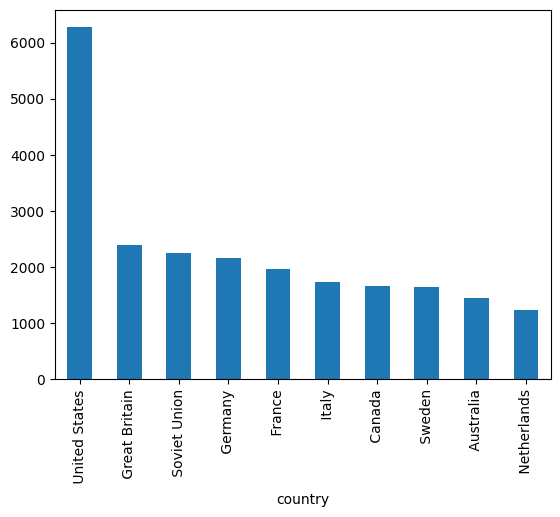

In [26]:
import matplotlib.pyplot as plt

top10 = quadro.sum(axis=1).sort_values(ascending=False).head(10)

top10.plot(kind='bar')
plt.savefig('gold/analise_medalhas/medalhas_plot.png')

In [27]:
modalidades = dados['sport'].value_counts().reset_index()
modalidades.columns = ['modalidade', 'total']

modalidades.to_csv('gold/analise_modalidades/modalidades_summary.csv', index=False)

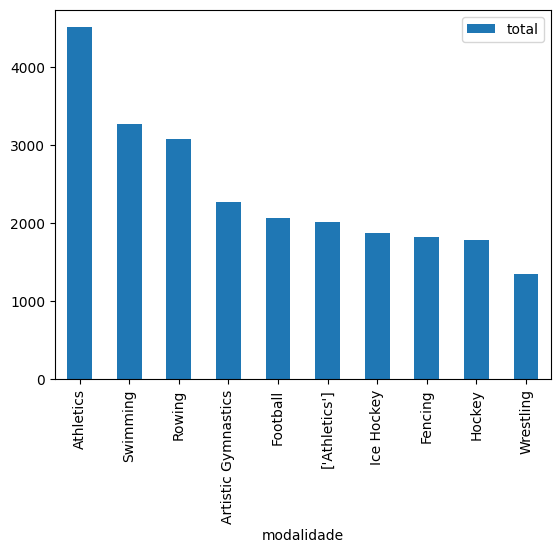

In [28]:
import matplotlib.pyplot as plt

top10 = modalidades.head(10)

top10.plot(x='modalidade', y='total', kind='bar')

plt.savefig('gold/analise_modalidades/modalidades_plot.png')

In [29]:
genero = dados['sex'].value_counts().reset_index()
genero.columns = ['sexo', 'total']

genero.to_csv('gold/analise_genero/genero_summary.csv', index=False)

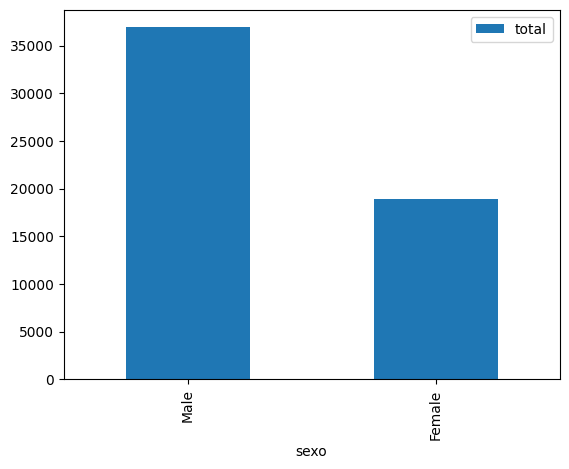

In [30]:
genero.plot(x='sexo', y='total', kind='bar')

plt.savefig('gold/analise_genero/genero_plot.png')